# Etap 5. projektu – Modelowanie

Projekt: **Automatyczne wykrywanie liczby klastrów w danych**

W poprzednich etapach przeprowadzono przygotowanie danych, analizę eksploracyjną oraz redukcję wymiarowości (PCA i t-SNE). W tym etapie budowane i porównywane są modele klasteryzacji, które stanowią główny przedmiot badań projektu.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

pd.set_option("display.max_columns", 100)
sns.set_theme()


## Wczytanie danych

In [2]:
DATA_PATH = "../data/processed/stage3_eda_ready.parquet"

data = pd.read_parquet(DATA_PATH)

exclude_columns = [
    "ID",
    "default.payment.next.month"
]

features = [c for c in data.columns if c not in exclude_columns]

X = data[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X.shape)


(30000, 13)


## Redukcja wymiarowości

Zgodnie z wynikami etapu 4 wykorzystujemy PCA do wizualizacji i wspomagania interpretacji klastrów.


In [3]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(
    "Zachowana wariancja:",
    round(np.sum(pca.explained_variance_ratio_), 4)
)


Zachowana wariancja: 0.3195


# Model 1 – K-Means

K-Means stanowi naturalny punkt odniesienia dla projektu, ponieważ metody Elbow, Silhouette Score oraz Gap Statistic są najczęściej wykorzystywane właśnie do wyznaczania liczby klastrów dla tego algorytmu.


In [4]:
kmeans_results = []

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    kmeans_results.append((k, score))

results_df = pd.DataFrame(
    kmeans_results,
    columns=["k", "silhouette"]
)

results_df


,k,silhouette
0,2,0.141996
1,3,0.162778
2,4,0.173714
3,5,0.149512
4,6,0.163529
5,7,0.149207
6,8,0.160039
7,9,0.147405
8,10,0.155977


In [5]:
best_k = results_df.loc[
    results_df["silhouette"].idxmax(),
    "k"
]

best_k = int(best_k)

print("Najlepsza liczba klastrów:", best_k)


Najlepsza liczba klastrów: 4


In [6]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_silhouette = silhouette_score(
    X_scaled,
    kmeans_labels
)

print("Silhouette Score:", round(kmeans_silhouette, 4))


Silhouette Score: 0.1737


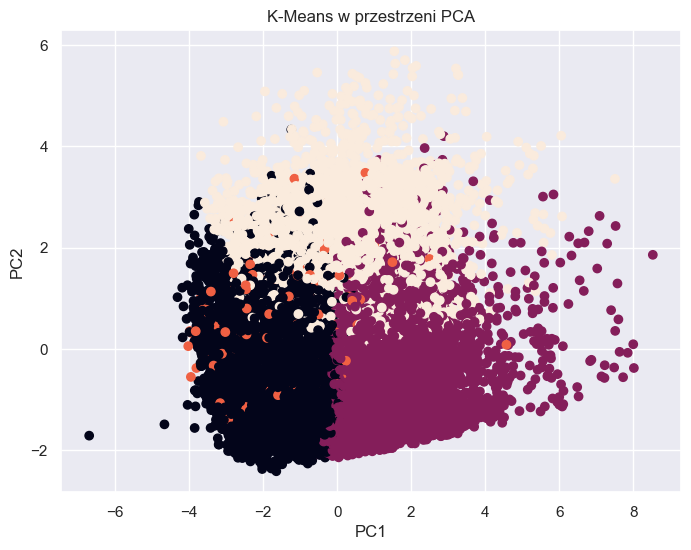

In [7]:
plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=kmeans_labels
)

plt.title("K-Means w przestrzeni PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


# Model 2 – Agglomerative Clustering

Klasteryzacja hierarchiczna pozwala sprawdzić, czy struktura danych jest zgodna z wynikami uzyskanymi przez K-Means.


In [8]:
agg_model = AgglomerativeClustering(
    n_clusters=best_k
)

agg_labels = agg_model.fit_predict(X_scaled)

agg_silhouette = silhouette_score(
    X_scaled,
    agg_labels
)

print("Silhouette Score:", round(agg_silhouette, 4))


Silhouette Score: 0.1532


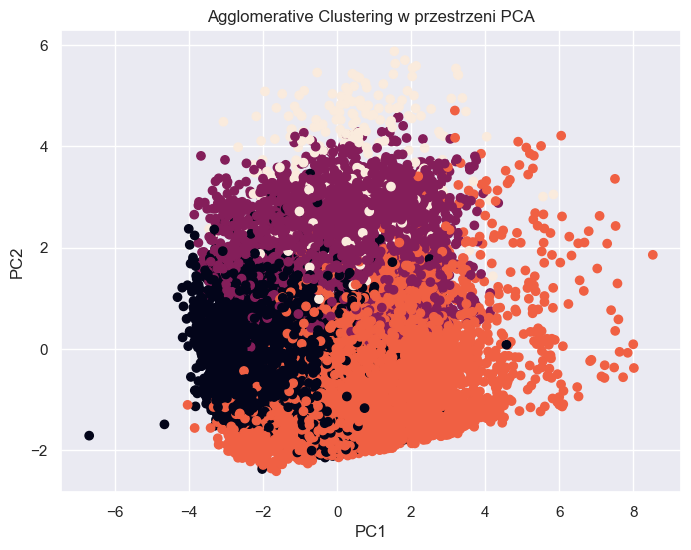

In [9]:
plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=agg_labels
)

plt.title("Agglomerative Clustering w przestrzeni PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


# Model 3 – DBSCAN

DBSCAN umożliwia wykrywanie skupień o nieregularnych kształtach oraz identyfikację obserwacji odstających.


In [10]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=10
)

dbscan_labels = dbscan.fit_predict(X_scaled)

unique_labels = np.unique(dbscan_labels)

if len(unique_labels) > 1 and np.sum(dbscan_labels != -1) > 0:
    dbscan_silhouette = silhouette_score(
        X_scaled,
        dbscan_labels
    )
else:
    dbscan_silhouette = np.nan

print("Liczba grup:", len(unique_labels))
print("Silhouette:", dbscan_silhouette)


Liczba grup: 22
Silhouette: 0.14975748661806995


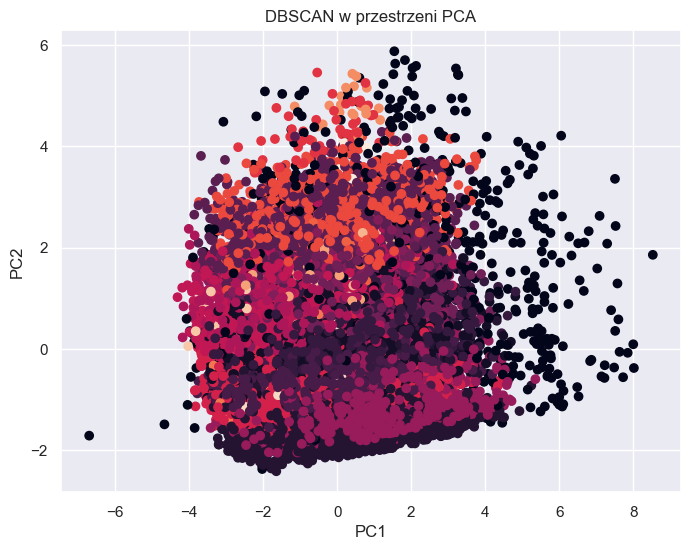

In [11]:
plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=dbscan_labels
)

plt.title("DBSCAN w przestrzeni PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


## Porównanie modeli

In [12]:
comparison = pd.DataFrame({
    "Model": [
        "K-Means",
        "Agglomerative",
        "DBSCAN"
    ],
    "Silhouette Score": [
        kmeans_silhouette,
        agg_silhouette,
        dbscan_silhouette
    ]
})

comparison.sort_values(
    "Silhouette Score",
    ascending=False
)


,Model,Silhouette Score
0,K-Means,0.173714
1,Agglomerative,0.153233
2,DBSCAN,0.149757


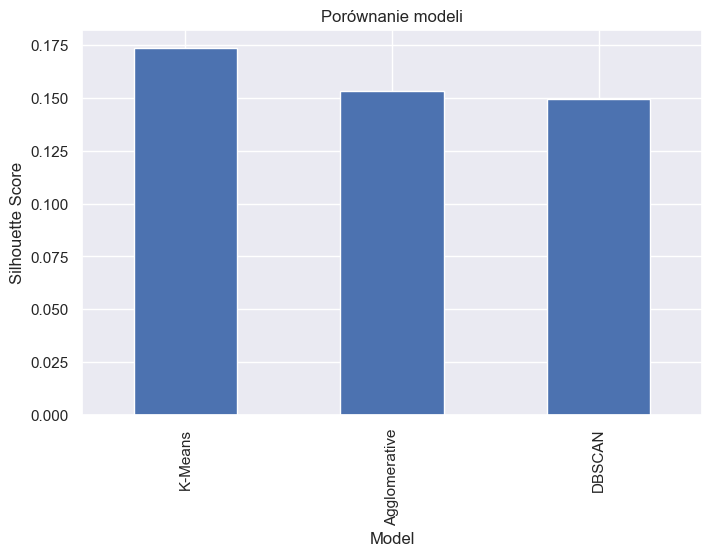

In [13]:
comparison.plot(
    x="Model",
    y="Silhouette Score",
    kind="bar",
    legend=False,
    figsize=(8,5)
)

plt.ylabel("Silhouette Score")
plt.title("Porównanie modeli")
plt.show()


## Interpretacja wyników

### K-Means
- model bazowy projektu,
- bezpośrednio związany z metodami Elbow, Silhouette oraz Gap Statistic,
- dobrze działa dla klastrów o zbliżonym kształcie.

### Agglomerative Clustering
- pozwala analizować strukturę hierarchiczną,
- może lepiej odwzorowywać zależności między grupami.

### DBSCAN
- wykrywa obserwacje odstające,
- nie wymaga podawania liczby klastrów,
- jest wrażliwy na dobór parametrów eps i min_samples.


# Wnioski końcowe

1. Porównano trzy różne modele klasteryzacji zgodnie z wymaganiami etapu 5.
2. Do oceny wykorzystano Silhouette Score oraz analizę wizualną przestrzeni PCA.
3. Najlepszy model należy wybrać na podstawie jakości klasteryzacji oraz interpretowalności wyników.
4. Uzyskane rezultaty należy zestawić z wynikami metod wyznaczania liczby klastrów analizowanych w projekcie.
5. Redukcja wymiarowości z etapu 4 ułatwia interpretację oraz wizualizację uzyskanych klastrów.
